In [2]:
%pip install qiskit-aer

Note: you may need to restart the kernel to use updated packages.


In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
import json
from pathlib import Path
from qiskit.circuit.classical import expr

In [6]:
#qc = QuantumCircuit(4)
def entangler(n):
    if n%2 == 1:
        raise("Error. Must me even number")
    qc = QuantumCircuit(n)
    for i in range(int(n/2)):
        qc.h(i)
        qc.cx(i,n-i-1)
    return qc

entangler(4).draw(output='text')

┌───┐          
q_0: ┤ H ├──■───────
     ├───┤  │       
q_1: ┤ H ├──┼────■──
     └───┘  │  ┌─┴─┐
q_2: ───────┼──┤ X ├
          ┌─┴─┐└───┘
q_3: ─────┤ X ├─────
          └───┘

In [10]:
#Commence cross-contamination
q=4
qr,cr = QuantumRegister(q),ClassicalRegister(q+1)
q2 = QuantumCircuit(qr,cr)
q2.compose(entangler(q),inplace=True)
q2.barrier()
q2.barrier()
q2.barrier()
#X correction
xflip(q2)
q2.barrier()
zflip(q2)
q2.barrier()
#Zcorrection
#display(Statevector(q2).draw("latex"))

q2.measure(0,0)
q2.measure(3,1)

with q2.if_test((cr[0], 0)):
    q2.z(1)

with q2.if_test((cr[0], 0)):
    q2.x(1)

with q2.if_test(expr.equal(cr[0], cr[1])) as else_:
    q2.store(cr[4], True)
    
with else_:
    q2.store(cr[4], False) 
   
q2.cx(1,2)
q2.h(1)
q2.measure(1,2)
q2.measure(2,3)

q2.draw(output='text')


┌───┐           ░  ░  ░ ┌───┐ ░      ┌───┐ ░ ┌─┐                    »
q4_0: ┤ H ├──■────────░──░──░─┤ X ├─░───■──┤ H ├─░─┤M├────────────────────»
      ├───┤  │        ░  ░  ░ └─┬─┘ ░ ┌─┴─┐└───┘ ░ └╥┘     ┌──────   ┌───┐»
q4_1: ┤ H ├──┼────■───░──░──░───■───░─┤ X ├──────░──╫──────┤ If-0  ──┤ Z ├»
      └───┘  │  ┌─┴─┐ ░  ░  ░       ░ ├───┤      ░  ║      └──╥───   └───┘»
q4_2: ───────┼──┤ X ├─░──░──░───■───░─┤ X ├──────░──╫─────────╫───────────»
           ┌─┴─┐└───┘ ░  ░  ░ ┌─┴─┐ ░ └─┬─┘┌───┐ ░  ║ ┌─┐     ║           »
q4_3: ─────┤ X ├──────░──░──░─┤ X ├─░───■──┤ H ├─░──╫─┤M├─────╫───────────»
           └───┘      ░  ░  ░ └───┘ ░      └───┘ ░  ║ └╥┘┌────╨─────┐     »
c4: 5/══════════════════════════════════════════════╩══╩═╡ c4_0=0x0 ╞═════»
                                                    0  1 └──────────┘     »
«                                                         
«q4_0: ───────────────────────────────────────────────────
«       ───────┐   ┌──────   ┌───┐ ───────┐       ┌───┐┌─┐
«q4_1:   End-0 ├───┤ If-0  ──┤ X ├  End-0 ├────■──┤ H ├┤M├
«       ───────┘   └──╥───   └───┘ ───────┘  ┌─┴─┐└┬─┬┘└╥┘
«q4_2: ───────────────╫──────────────────────┤ X ├─┤M├──╫─
«                     ║                      └───┘ └╥┘  ║ 
«q4_3: ───────────────╫─────────────────────────────╫───╫─
«                ┌────╨─────┐                       ║   ║ 
«c4: 5/══════════╡ c4_0=0x0 ╞═══════════════════════╩═══╩═
«                └──────────┘                       3   2

In [9]:
def xflip(q2):
    q2.cx(1,0)
    q2.cx(2,3)

def zflip(q2):
    q2.cx(0,1)
    q2.h(0)
    q2.cx(3,2)
    q2.h(3)

{'00000': 61, '00011': 67}
{'00': 61, '01': 67}
128


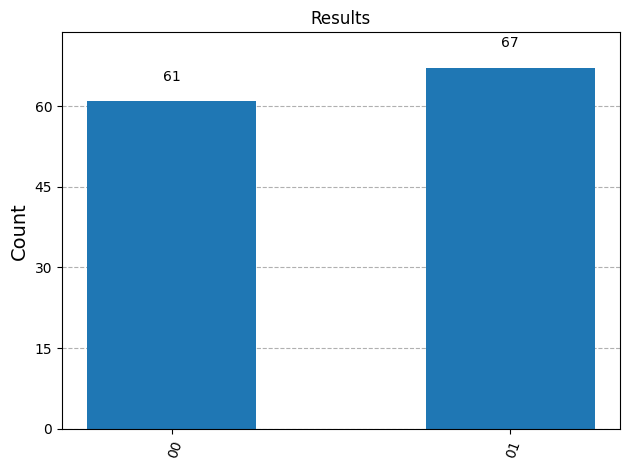

In [83]:
#With Aer simulator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
simulator = AerSimulator()
circ = transpile(q2, simulator)

# Run and get counts
result = simulator.run(circ,shots = 128).result()
counts = result.get_counts(circ)
print(counts) 

new_counts = {}
true_shots = 0

#The classical logic was implemented in the circuit. This next part is only for visual appeal
for key,number in counts.items():
    if key[4]==1:
        continue

    new_counts[key[2:4]]=number
    true_shots+=number

print(new_counts)
print(true_shots)
plot_histogram(new_counts, title='Results')